Simple program where we:

* Generate fake data
    * plot scatter
* Define hypothesis
* Define cost
    * Lest squares, cross-function
* Implement gradient descent
    * loop updating theta
* Plot learned line
    * Compare against data
* Print learned theta
    * Check if close to truth

In [1]:
import numpy as np
import matplotlib.pyplot as plt

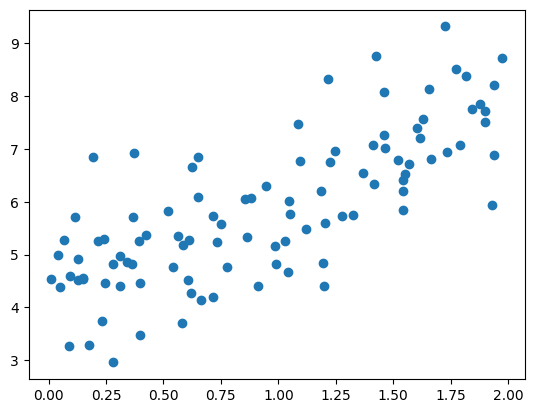

In [2]:
np.random.seed(42)

m = 100 #training examples
n = 1 #features

x = np.array(2 * np.random.rand(m, 1)) #random input values
y = np.array(2 * x + 4 + np.random.randn(m, 1)) #outputs with normally distributed noise

X = np.hstack((np.ones((m,1)), x)) #matrix X with the stacked inputs

plt.scatter(x,y)
plt.show()

In [3]:
def predict(X, theta):
    # h(theta)
    return X @ theta 


def cost_function(X, y, theta):
    # J(theta)
    m = len(y)
    errors = predict(X, theta) - y
    return 0.5 * np.sum(errors ** 2) / m


def gradient_descent(X, y, theta, alpha, iterations):
    # Batch gradient descent, training to choose the most optimal theta
    cost_history = []
    m = len(y)
    n = len(theta)

    for _ in range(iterations):
        new_theta = theta.copy()
        errors = predict(X, theta) - y

        for j in range(n):
            summation = 0

            for i in range(m):
                summation += errors[i] * X[i, j]

            new_theta[j] = theta[j] - alpha * summation / m

        theta = new_theta
        cost_history.append(cost_function(X, y, theta))

    return theta, cost_history

[[4.21479946]
 [1.77037535]]


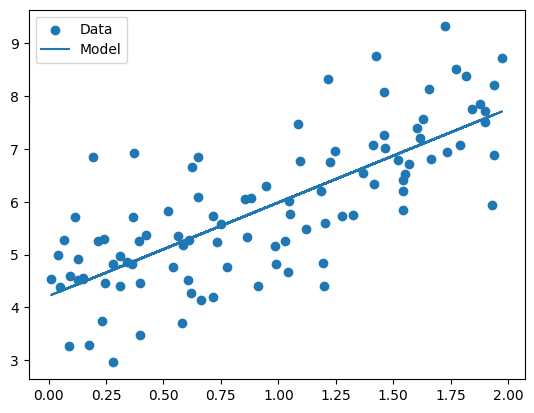

In [34]:
theta = np.zeros((n+1, 1)) #initial parameter value
alpha = 0.05 #learning rate
iterations = 1000

theta, cost_history = gradient_descent(X, y, theta, alpha, iterations)

print(theta)
y_pred = predict(X, theta)

plt.scatter(x, y, label = "Data")
plt.plot(x, y_pred, label = "Model")

plt.legend()
plt.show()

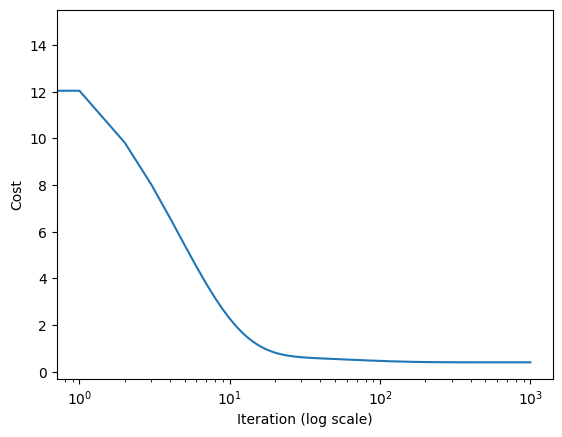

In [35]:
plt.plot(cost_history)
plt.xlabel("Iteration (log scale)")
plt.ylabel("Cost")
plt.xscale('log')
plt.show()